In [21]:
# ============================================================
# SAP Pipeline (FULL) – OLD nur zum Vergleich, NEW ist das Working-Set
# Ziel:
# - OLD = "../Data/SAP Bilder sortiert" bleibt unverändert
# - NEW = "../Data/SAP mit Pseudo Labels" ist das aktive Dataset
# - CLIP Top-up schreibt NUR nach NEW und kann Quellen aus "Rest Ungelabelt" entfernen (archiviert)
# - rest_candidate.csv wird danach automatisch bereinigt (damit du anschließend sauber weiterarbeiten kannst)
# ============================================================

# 0) Setup: Imports, Seeds, Paths, Device + Watchdog
# ============================================================
from pathlib import Path
import random
import shutil
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Determinismus deaktivieren (Warnung vermeiden, Training stabil/schneller) ---
torch.use_deterministic_algorithms(False)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True  # zentral gesetzt

# --- Reproduzierbarkeit ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Optional: Performance
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


# --- Device Logik: CUDA nur, wenn ein echter Kernel-Call klappt ---
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.randn(1, device="cuda")  # erzwingt echten Kernel-Launch
            return torch.device("cuda:0")
        except Exception as e:
            print("[WARN] CUDA erkannt, aber nicht nutzbar -> CPU-Fallback.")
            print("       Ursache:", str(e).splitlines()[0])
    return torch.device("cpu")


TORCH_DEVICE = pick_device()
CUDA_USABLE = (TORCH_DEVICE.type == "cuda")
YOLO_DEVICE = 0 if CUDA_USABLE else "cpu"  # Ultralytics: 0 = GPU0, sonst "cpu"

print("CUDA available (torch):", torch.cuda.is_available())
print("CUDA usable (kernel test):", CUDA_USABLE)
print("TORCH_DEVICE:", TORCH_DEVICE)
print("YOLO_DEVICE:", YOLO_DEVICE)
if CUDA_USABLE:
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

# --- Pfade ---
DATA_DIR = Path("..") / "Data"

LABELED_DIR_OLD = DATA_DIR / "SAP Bilder sortiert"
LABELED_DIR_NEW = DATA_DIR / "SAP mit Pseudo Labels"
UNLABELED_DIR = DATA_DIR / "Rest Ungelabelt"

# WICHTIG: ab hier arbeitet alles auf NEW
LABELED_DIR = LABELED_DIR_NEW

WORK_DIR = Path("..") / "Work"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# --- NEW initialisieren (nur wenn NEW leer ist) ---
# Wenn NEW bereits gefüllt ist: lässt es in Ruhe.
INIT_NEW_FROM_OLD_IF_EMPTY = True
LABELED_DIR_NEW.mkdir(parents=True, exist_ok=True)
if INIT_NEW_FROM_OLD_IF_EMPTY and LABELED_DIR_OLD.exists() and not any(LABELED_DIR_NEW.iterdir()):
    shutil.copytree(LABELED_DIR_OLD, LABELED_DIR_NEW, dirs_exist_ok=True)
    print("[INIT] Kopiert OLD -> NEW (weil NEW leer war).")
    print("OLD:", LABELED_DIR_OLD)
    print("NEW:", LABELED_DIR_NEW)


# --- Hilfsfunktionen ---
def is_image(p: Path):
    return p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}


def list_images(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.is_file() and is_image(p)])


# ---------- GPU Watchdog ----------
MIN_FREE_MB_DEFAULT = 1500  # wenn weniger frei -> CPU-Fallback (anpassen nach Gefühl)


def _bytes_to_mb(x):
    return float(x) / (1024 ** 2)


def cuda_mem_status():
    if not torch.cuda.is_available():
        return {"cuda": False}
    free_b, total_b = torch.cuda.mem_get_info()
    alloc_b = torch.cuda.memory_allocated()
    res_b = torch.cuda.memory_reserved()
    return {
        "cuda": True,
        "total_mb": _bytes_to_mb(total_b),
        "free_mb": _bytes_to_mb(free_b),
        "allocated_mb": _bytes_to_mb(alloc_b),
        "reserved_mb": _bytes_to_mb(res_b),
        "device": torch.cuda.get_device_name(0),
        "capability": torch.cuda.get_device_capability(0),
    }


def clear_jupyter_out_cache():
    # optional: kann helfen, wenn Out[] / _ große Objekte hält
    try:
        ip = get_ipython()  # noqa
        if "Out" in ip.user_ns:
            ip.user_ns["Out"].clear()
        for k in ["_", "__", "___"]:
            if k in ip.user_ns:
                ip.user_ns[k] = None
    except Exception:
        pass


def cuda_cleanup(clear_out_cache=False):
    if clear_out_cache:
        clear_jupyter_out_cache()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
    gc.collect()


def ensure_best_device(min_free_mb=MIN_FREE_MB_DEFAULT, prefer_gpu=True, clear=True):
    """
    Wählt GPU wenn genug frei, sonst CPU. Macht optional Cleanup.
    Rückgabe: (device, use_cuda_bool)
    """
    if clear:
        cuda_cleanup(clear_out_cache=False)

    if prefer_gpu and torch.cuda.is_available():
        free_b, _total_b = torch.cuda.mem_get_info()
        free_mb = free_b / (1024 ** 2)
        if free_mb >= float(min_free_mb):
            return torch.device("cuda:0"), True
    return torch.device("cpu"), False


def watchdog(min_free_mb=MIN_FREE_MB_DEFAULT, auto_set=True, clear=True, clear_out_cache=False):
    """
    Zeigt Status, macht Cleanup und setzt optional TORCH_DEVICE/CUDA_USABLE/YOLO_DEVICE passend.
    """
    before = cuda_mem_status()
    print("---- CUDA status (before) ----")
    print(before)

    if clear:
        cuda_cleanup(clear_out_cache=clear_out_cache)
    after = cuda_mem_status()
    print("---- CUDA status (after cleanup) ----")
    print(after)

    if auto_set:
        global TORCH_DEVICE, CUDA_USABLE, YOLO_DEVICE
        if after.get("cuda", False) and after["free_mb"] >= float(min_free_mb):
            TORCH_DEVICE = torch.device("cuda:0")
            CUDA_USABLE = True
            YOLO_DEVICE = 0
            print(f"[WATCHDOG] Using GPU (free {after['free_mb']:.0f} MB >= {min_free_mb} MB).")
        else:
            TORCH_DEVICE = torch.device("cpu")
            CUDA_USABLE = False
            YOLO_DEVICE = "cpu"
            if after.get("cuda", False):
                print(f"[WATCHDOG] GPU too full (free {after['free_mb']:.0f} MB < {min_free_mb} MB) -> CPU fallback.")
            else:
                print("[WATCHDOG] CUDA not available -> CPU fallback.")

    return after

CUDA available (torch): True
CUDA usable (kernel test): True
TORCH_DEVICE: cuda:0
YOLO_DEVICE: 0
GPU: NVIDIA GeForce RTX 5080
Capability: (12, 0)


OLD: ..\Data\SAP Bilder sortiert


,class,count
10,Excel,75
11,Query,72
4,Data Flow Object,44
9,DTP,42
8,Datenvorschau,41
12,Transformationen,39
2,BW4Cockpit (Stammdaten),38
0,ABAP Dictionary,33
6,Data Source,28
3,Composite Provider,17


NEW: ..\Data\SAP mit Pseudo Labels


,class,count
10,Excel,75
11,Query,72
0,ABAP Dictionary,50
2,BW4Cockpit (Stammdaten),50
4,Data Flow Object,50
6,Data Source,50
8,Datenvorschau,50
9,DTP,50
12,Transformationen,50
7,Data Store Object,49


,class,count
10,Excel,75
11,Query,72
0,ABAP Dictionary,50
2,BW4Cockpit (Stammdaten),50
4,Data Flow Object,50
6,Data Source,50
8,Datenvorschau,50
9,DTP,50
12,Transformationen,50
7,Data Store Object,49


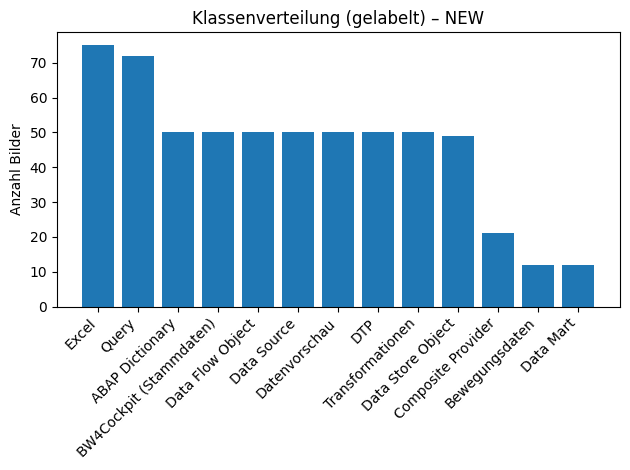

In [22]:
# 0b) Vergleich OLD vs NEW (nur zur Verifizierung)
# ============================================================
def class_counts(root: Path) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(columns=["class", "count"])
    for cls_dir in root.iterdir():
        if not cls_dir.is_dir():
            continue
        n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
        rows.append({"class": cls_dir.name, "count": n})
    return pd.DataFrame(rows).sort_values("count", ascending=False)


print("OLD:", LABELED_DIR_OLD)
display(class_counts(LABELED_DIR_OLD))

print("NEW:", LABELED_DIR_NEW)
display(class_counts(LABELED_DIR_NEW))

# 1) Klassenverteilung anzeigen (gelabelt) – arbeitet auf NEW
# ============================================================
rows = []
for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df)

plt.figure()
plt.bar(df["class"], df["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt) – NEW")
plt.tight_layout()
plt.show()

In [23]:
# 2) Optional: Downsample-Plan berechnen (cap/target) – NEW
# ============================================================
counts = {}
for cls_dir in LABELED_DIR.iterdir():
    if cls_dir.is_dir():
        counts[cls_dir.name] = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))

s = pd.Series(counts).sort_values(ascending=False)
print("Counts:\n", s)

cap = 75
target = 50

downsample = (s - cap).clip(lower=0).astype(int)      # wie viele entfernen
topup      = (target - s).clip(lower=0).astype(int)   # wie viele ergänzen

print("\nDownsample (remove):\n", downsample[downsample > 0])
print("\nUnderrepresented vs target:\n", topup[topup > 0])
print("\nTotal missing to reach target:", int(topup.sum()))

Counts:
 Excel                      75
Query                      72
ABAP Dictionary            50
BW4Cockpit (Stammdaten)    50
Data Flow Object           50
Data Source                50
Datenvorschau              50
DTP                        50
Transformationen           50
Data Store Object          49
Composite Provider         21
Bewegungsdaten             12
Data Mart                  12
dtype: int64

Downsample (remove):
 Series([], dtype: int32)

Underrepresented vs target:
 Data Store Object      1
Composite Provider    29
Bewegungsdaten        38
Data Mart             38
dtype: int32

Total missing to reach target: 106


In [24]:
# 3) Optional: Downsample wirklich durchführen (Bilder wegbewegen) – NEW
# ============================================================
DO_DOWNSAMPLE = False  # <- auf True, wenn du wirklich Bilder verschieben willst

REDUCED_DIR = WORK_DIR / "reduced"
REDUCED_DIR.mkdir(parents=True, exist_ok=True)

rng = random.Random(seed)

def move_random_images(cls_name: str, n_remove: int):
    src_dir = LABELED_DIR / cls_name
    if not src_dir.exists():
        print(f"[WARN] Klasse nicht gefunden: {cls_name}")
        return 0

    imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image(p)]
    if n_remove <= 0:
        return 0

    rng.shuffle(imgs)
    to_move = imgs[:min(n_remove, len(imgs))]

    dst_dir = REDUCED_DIR / cls_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    for p in to_move:
        shutil.move(str(p), str(dst_dir / p.name))

    return len(to_move)

if DO_DOWNSAMPLE:
    removed_total = 0
    for cls_name, n_remove in downsample.items():
        n_remove = int(n_remove)
        if n_remove > 0:
            moved = move_random_images(cls_name, n_remove)
            removed_total += moved
            print(f"Reduced {cls_name}: moved {moved} images -> {REDUCED_DIR / cls_name}")
    print("Total moved:", removed_total)
else:
    print("DO_DOWNSAMPLE=False -> nichts verschoben.")

DO_DOWNSAMPLE=False -> nichts verschoben.


In [25]:
# 4) Rest Ungelabelt: Holdout/Candidate Split (CSV)
# ============================================================
DO_UNLABELED_SPLIT = True

SPLITS_DIR = DATA_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

if DO_UNLABELED_SPLIT:
    unlabeled_all = list_images(UNLABELED_DIR)
    print("Rest Ungelabelt total:", len(unlabeled_all))

    holdout_ratio = 0.50
    idx = list(range(len(unlabeled_all)))
    rng.shuffle(idx)

    holdout_n = int(len(unlabeled_all) * holdout_ratio)
    holdout_idx = set(idx[:holdout_n])

    unlabeled_holdout   = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i in holdout_idx]
    unlabeled_candidate = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i not in holdout_idx]

    print("Holdout:", len(unlabeled_holdout))
    print("Candidate:", len(unlabeled_candidate))

    pd.DataFrame({"path": [str(p) for p in unlabeled_holdout]}).to_csv(SPLITS_DIR / "rest_holdout.csv", index=False)
    pd.DataFrame({"path": [str(p) for p in unlabeled_candidate]}).to_csv(SPLITS_DIR / "rest_candidate.csv", index=False)
else:
    print("DO_UNLABELED_SPLIT=False -> keine CSVs erzeugt.")

Rest Ungelabelt total: 2827
Holdout: 1413
Candidate: 1414


In [6]:
"""
# 4b) Algorithmisches Auffüllen der 3 fehlenden Klassen via Zero-Shot CLIP
#     -> nutzt NUR rest_candidate.csv (Holdout bleibt unberührt)
#     -> schreibt NUR nach NEW (LABELED_DIR = "SAP mit Pseudo Labels")
#     -> entfernt optional die verwendeten Bilder aus "Rest Ungelabelt" (verschiebt ins Work-Archiv)
#     -> aktualisiert rest_candidate.csv (damit später weitere Schritte sauber sind)
# ============================================================
# TODO nicht nochmal ausführen
import sys, re, time
from heapq import heappush, heapreplace
from PIL import Image

# ---------- Einstellungen ----------
TARGET = int(globals().get("target", 50))
DESIRED_CLASSES = ["Composite Provider", "Data Mart", "Bewegungsdaten"]

CAND_CSV = SPLITS_DIR / "rest_candidate.csv"

# konservativ starten; wenn zu wenig gefunden wird:
CONF_THR   = 0.80   # z.B. 0.75 oder 0.70
MARGIN_THR = 0.10   # z.B. 0.05
KEEP_FACTOR = 3     # hält need*KEEP_FACTOR pro Klasse im Heap

# WICHTIG für deine Frage:
# - Ja: wird nach NEW in passende Klassenordner einsortiert
# - Ja: wird aus Rest Ungelabelt entfernt, aber sicher archiviert (kein Löschen)
MOVE_FROM_UNLABELED = True
ARCHIVE_DIR = WORK_DIR / "moved_from_rest_ungelabelt"
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

AUDIT_PATH = WORK_DIR / "clip_topup_audit.csv"

def _norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]", "", s.lower())

def count_images_in_dir(d: Path) -> int:
    if not d.exists():
        return 0
    return sum(1 for f in d.iterdir() if f.is_file() and is_image(f))

# Ordner-Mapping: falls Ordnernamen minimal abweichen, wird robust gemappt
existing_dirs = [d for d in LABELED_DIR.iterdir() if d.is_dir()]
existing_norm = {_norm(d.name): d.name for d in existing_dirs}

CLASS_MAP = {}
for desired in DESIRED_CLASSES:
    nd = _norm(desired)
    if nd in existing_norm:
        CLASS_MAP[desired] = existing_norm[nd]
    else:
        CLASS_MAP[desired] = desired  # wird neu angelegt

for desired, real in CLASS_MAP.items():
    (LABELED_DIR / real).mkdir(parents=True, exist_ok=True)

print("TARGET:", TARGET)
print("LABELED_DIR (NEW):", LABELED_DIR)
print("CLASS_MAP:", CLASS_MAP)

counts_3 = {cls: count_images_in_dir(LABELED_DIR / CLASS_MAP[cls]) for cls in DESIRED_CLASSES}
s3 = pd.Series(counts_3).sort_values(ascending=False)
topup3 = (TARGET - s3).clip(lower=0).astype(int)
need = {k: int(v) for k, v in topup3.to_dict().items() if int(v) > 0}

print("Aktuelle Counts (3 Klassen):\n", s3)
print("Fehlend bis TARGET:\n", topup3)
print("Need:", need)

if not need:
    print("Nichts zu tun – alle 3 Klassen sind bereits >= TARGET.")
else:
    if not CAND_CSV.exists():
        raise FileNotFoundError(f"Candidate CSV fehlt: {CAND_CSV} (bitte Zelle #4 ausführen)")

    cand_paths = pd.read_csv(CAND_CSV)["path"].map(Path).tolist()
    cand_paths = [p for p in cand_paths if p.exists()]
    print(f"Candidate via CSV: {CAND_CSV} | n={len(cand_paths)}")

    # CLIP installieren & laden
    try:
        import open_clip
    except Exception:
        !{sys.executable} -m pip -q install open_clip_torch
        import open_clip

    clip_dev, _ = ensure_best_device(min_free_mb=2000, prefer_gpu=True, clear=True)
    print("CLIP device:", clip_dev)

    model_name = "ViT-B-32"
    pretrained = "openai"

    clip_model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(model_name)
    clip_model = clip_model.to(clip_dev).eval()

    logit_scale = getattr(clip_model, "logit_scale", None)
    logit_scale = float(logit_scale.exp().item()) if logit_scale is not None else 1.0

    # Prompts – passend zu deinen Screenshots (Editor/CSV/Eclipse/SAP BW)
    PROMPTS = {
        "Composite Provider": [
            "SAP BW CompositeProvider in Eclipse modelling screen",
            "BW modelling view with Union node and mapping arrows",
            "SAP BW Composite Provider editor scenario view screenshot",
            "SAP BW Modellierung CompositeProvider Union Screenshot",
        ],
        "Data Mart": [
            "SAP BW DataStore-Objekt advanced data mart selected",
            "Data-Mart-DataStore-Objekt radio button selected",
            "BW reporting preview table with KPIs and overall result",
            "SAP BW Data Mart Hochschuldaten Screenshot",
        ],
        "Bewegungsdaten": [
            "CSV file with semicolon separated values Bundesland Semester Fachbereich",
            "Notepad text file with many rows of numeric movement data",
            "Bewegungsdaten CSV in editor screenshot",
            "dataset lines with tokens like SS16 FB01 and numeric values",
        ],
    }

    classes = list(need.keys())

    @torch.no_grad()
    def build_text_stack(classes_):
        feats = []
        for cls in classes_:
            plist = PROMPTS[cls]
            tok = tokenizer(plist).to(clip_dev)
            tf = clip_model.encode_text(tok)
            tf = tf / tf.norm(dim=-1, keepdim=True)
            tf = tf.mean(dim=0, keepdim=True)
            tf = tf / tf.norm(dim=-1, keepdim=True)
            feats.append(tf)
        return torch.cat(feats, dim=0)

    text_stack = build_text_stack(classes)

    BATCH = 64 if clip_dev.type == "cuda" else 16

    heaps = {cls: [] for cls in classes}  # min-heap nach conf
    kept_limits = {cls: max(need[cls] * KEEP_FACTOR, need[cls]) for cls in classes}

    def iter_batches(lst, bs):
        for i in range(0, len(lst), bs):
            yield lst[i:i+bs]

    @torch.no_grad()
    def score_paths(paths):
        imgs, ok = [], []
        for p in paths:
            try:
                img = Image.open(p).convert("RGB")
                imgs.append(preprocess(img))
                ok.append(p)
            except Exception:
                continue
        if not imgs:
            return [], None, None, None

        x = torch.stack(imgs, dim=0).to(clip_dev)
        img_feat = clip_model.encode_image(x)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        logits = (img_feat @ text_stack.T) * logit_scale
        probs = torch.softmax(logits, dim=1)
        top2 = torch.topk(probs, k=min(2, probs.shape[1]), dim=1)
        return ok, probs.detach().cpu().numpy(), top2.indices.detach().cpu().numpy(), top2.values.detach().cpu().numpy()

    t0 = time.time()
    scored = 0

    for chunk in iter_batches(cand_paths, BATCH):
        ok, probs, top2_idx, top2_vals = score_paths(chunk)
        if probs is None:
            continue

        for i, p in enumerate(ok):
            scored += 1
            j1 = int(top2_idx[i][0])
            c1 = float(top2_vals[i][0])
            c2 = float(top2_vals[i][1]) if top2_vals.shape[1] > 1 else 0.0
            margin = c1 - c2

            pred_cls = classes[j1]
            if c1 < CONF_THR or margin < MARGIN_THR:
                continue

            heap = heaps[pred_cls]
            item = (c1, margin, str(p))
            if len(heap) < kept_limits[pred_cls]:
                heappush(heap, item)
            else:
                if item[0] > heap[0][0]:
                    heapreplace(heap, item)

    print(f"Scored={scored} images in {time.time()-t0:.1f}s | batch={BATCH} | device={clip_dev}")

    # Final selection
    selected_rows = []
    for cls in classes:
        heap_sorted = sorted(heaps[cls], key=lambda x: x[0], reverse=True)
        take = heap_sorted[:need[cls]]
        print(f"{cls}: kept={len(heaps[cls])} | take={len(take)} | need={need[cls]}")
        for conf, margin, path_str in take:
            selected_rows.append({"path": path_str, "pred": cls, "conf": conf, "margin": margin})

    df_sel = pd.DataFrame(selected_rows)
    print("Selected total:", len(df_sel))

    for cls in classes:
        have = int((df_sel["pred"] == cls).sum()) if len(df_sel) else 0
        if have < need[cls]:
            print(f"[WARN] {cls}: nur {have}/{need[cls]} gefunden. Senke ggf. CONF_THR (0.75) oder MARGIN_THR (0.05).")

    def unique_dest(dst_dir: Path, src: Path) -> Path:
        dst = dst_dir / src.name
        if not dst.exists():
            return dst
        return dst_dir / f"{src.stem}__dup{src.stat().st_size}{src.suffix}"

    actions = []
    moved_sources = set()

    for _, r in df_sel.iterrows():
        src = Path(r["path"])
        label = r["pred"]

        if not src.exists():
            continue

        dst_dir = LABELED_DIR / CLASS_MAP[label]
        dst_dir.mkdir(parents=True, exist_ok=True)

        dst = unique_dest(dst_dir, src)
        shutil.copy2(src, dst)

        arch = ""
        if MOVE_FROM_UNLABELED:
            # Sicher: nicht löschen, sondern ins Work-Archiv verschieben
            try:
                rel = src.relative_to(UNLABELED_DIR)
                arch_path = ARCHIVE_DIR / rel
            except Exception:
                arch_path = ARCHIVE_DIR / src.name

            arch_path.parent.mkdir(parents=True, exist_ok=True)
            if arch_path.exists():
                arch_path = ARCHIVE_DIR / f"{src.stem}__dup{src.stat().st_size}{src.suffix}"
            shutil.move(str(src), str(arch_path))
            moved_sources.add(str(src))
            arch = str(arch_path)

        actions.append({**r.to_dict(), "dst": str(dst), "archived_from_unlabeled_to": arch})

    pd.DataFrame(actions).to_csv(AUDIT_PATH, index=False)
    print("Pseudo-labeled added to NEW:", LABELED_DIR)
    print("Audit CSV:", AUDIT_PATH)

    if MOVE_FROM_UNLABELED and moved_sources:
        # rest_candidate.csv bereinigen (damit du danach sauber weiterarbeiten kannst)
        df_cand = pd.read_csv(CAND_CSV)
        df_cand = df_cand[~df_cand["path"].isin(moved_sources)].copy()
        df_cand.to_csv(CAND_CSV, index=False)
        print("Updated candidate CSV (removed moved paths):", CAND_CSV)
        print("Archived files to:", ARCHIVE_DIR)
        print("Moved count:", len(moved_sources))
"""

TARGET: 50
LABELED_DIR (NEW): ..\Data\SAP mit Pseudo Labels
CLASS_MAP: {'Composite Provider': 'Composite Provider', 'Data Mart': 'Data Mart', 'Bewegungsdaten': 'Bewegungsdaten'}
Aktuelle Counts (3 Klassen):
 Composite Provider    50
Data Mart             50
Bewegungsdaten        50
dtype: int64
Fehlend bis TARGET:
 Composite Provider    0
Data Mart             0
Bewegungsdaten        0
dtype: int32
Need: {}
Nichts zu tun – alle 3 Klassen sind bereits >= TARGET.


,class,count
10,Excel,75
11,Query,72
0,ABAP Dictionary,50
2,BW4Cockpit (Stammdaten),50
4,Data Flow Object,50
6,Data Source,50
8,Datenvorschau,50
9,DTP,50
12,Transformationen,50
7,Data Store Object,49


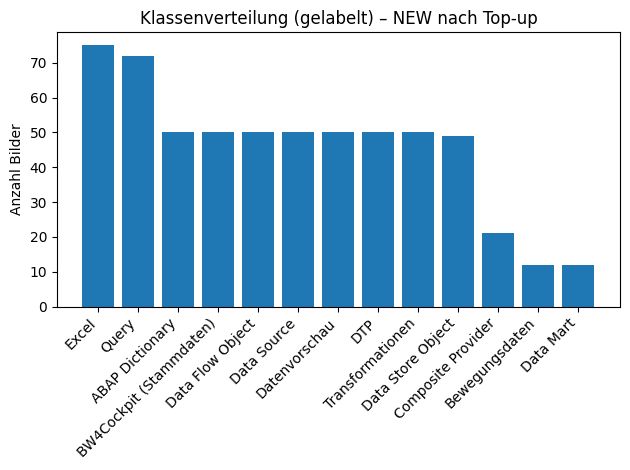

In [27]:
# 4c) Kontrolle: Klassenverteilung (NEW) nach dem Auffüllen
# ============================================================
rows = []
for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df2 = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df2)

plt.figure()
plt.bar(df2["class"], df2["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt) – NEW nach Top-up")
plt.tight_layout()
plt.show()

In [28]:
# 5) Train/Val Split als Ordnerstruktur (ImageFolder kompatibel) – aus NEW
# ============================================================
SPLIT_DIR = WORK_DIR / "datasets" / "base_split"
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

val_ratio = 0.2

def safe_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(src, dst)

for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    cls = cls_dir.name
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and is_image(p)]
    rng.shuffle(imgs)
    if len(imgs) == 0:
        continue

    n_val = max(1, int(len(imgs) * val_ratio))
    val_imgs = imgs[:n_val]
    train_imgs = imgs[n_val:]

    for p in train_imgs:
        safe_copy(p, TRAIN_DIR / cls / p.name)
    for p in val_imgs:
        safe_copy(p, VAL_DIR / cls / p.name)

print("Split erstellt:", SPLIT_DIR)

Split erstellt: ..\Work\datasets\base_split


In [29]:
# 6) YOLO Training (GPU wenn möglich; sonst CPU)
# ============================================================
from ultralytics import YOLO

watchdog(min_free_mb=2000, auto_set=True, clear=True)

yolo_model = YOLO("yolov8n-cls.pt")
yolo_model.train(
    data=str(SPLIT_DIR),
    imgsz=224,
    epochs=100,
    batch=32,      # falls OOM: 16 oder 8
    workers=2,     # falls Windows/Probleme: 0
    device=YOLO_DEVICE,
    verbose=True
)

DO_YOLO_VAL_AFTER_TRAIN = True
if DO_YOLO_VAL_AFTER_TRAIN:
    try:
        m2 = yolo_model.val(data=str(SPLIT_DIR), device=YOLO_DEVICE)
        print("YOLO finetuned:", m2)
    except Exception as e:
        print("[WARN] yolo_model.val() übersprungen/fehlgeschlagen:", str(e).splitlines()[0])

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14257.0, 'allocated_mb': 456.716796875, 'reserved_mb': 610.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14257.0, 'allocated_mb': 456.716796875, 'reserved_mb': 610.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14257 MB >= 2000 MB).
Ultralytics 8.3.252  Python-3.12.10 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Work\datasets\base_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=Fa

In [30]:
# 7) ResNet Setup (DataLoaders, Transforms, auto GPU/CPU)
# ============================================================
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

NUM_WORKERS = 0
BATCH_TRAIN = 32
BATCH_VAL   = 32

weights = models.ResNet18_Weights.IMAGENET1K_V1
val_tf = weights.transforms()
mean = weights.transforms().mean
std  = weights.transforms().std

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tf)
val_ds   = datasets.ImageFolder(str(VAL_DIR), transform=val_tf)

class_names = train_ds.classes
n_classes = len(class_names)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=CUDA_USABLE
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=CUDA_USABLE
)

print("Klassen (ImageFolder-Reihenfolge):", class_names)
print("n_classes:", n_classes)

Klassen (ImageFolder-Reihenfolge): ['ABAP Dictionary', 'BW4Cockpit (Stammdaten)', 'Bewegungsdaten', 'Composite Provider', 'DTP', 'Data Flow Object', 'Data Mart', 'Data Source', 'Data Store Object', 'Datenvorschau', 'Excel', 'Query', 'Transformationen']
n_classes: 13


In [31]:
# 8) ResNet Eval (auto GPU->CPU) + Baselines
# ============================================================
def eval_model_auto(model, loader, min_free_mb=1200):
    device, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    model = model.to(device).eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device, non_blocking=use_cuda)
            logits = model(x)
            pred = logits.argmax(dim=1).detach().cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc, device

# Baseline A: random
resnet_untrained = models.resnet18(weights=None)
resnet_untrained.fc = nn.Linear(resnet_untrained.fc.in_features, n_classes)

y_true, y_pred, acc, dev = eval_model_auto(resnet_untrained, val_loader)
print("RESNET untrained baseline acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Baseline B: pretrained backbone, neuer Kopf (untrainiert)
resnet_pre = models.resnet18(weights=weights)
resnet_pre.fc = nn.Linear(resnet_pre.fc.in_features, n_classes)

y_true, y_pred, acc, dev = eval_model_auto(resnet_pre, val_loader)
print("RESNET pretrained (no finetune) acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

RESNET untrained baseline acc: 0.05172413793103448 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       0.00      0.00      0.00        10
BW4Cockpit (Stammdaten)       0.00      0.00      0.00        10
         Bewegungsdaten       0.00      0.00      0.00         2
     Composite Provider       0.04      1.00      0.07         4
                    DTP       0.00      0.00      0.00        10
       Data Flow Object       0.00      0.00      0.00        10
              Data Mart       0.00      0.00      0.00         2
            Data Source       0.00      0.00      0.00        10
      Data Store Object       0.00      0.00      0.00         9
          Datenvorschau       0.18      0.20      0.19        10
                  Excel       0.00      0.00      0.00        15
                  Query       0.00      0.00      0.00        14
       Transformationen       0.00      0.00      0.00        10

               accur

In [32]:
# 9) ResNet Fine-Tuning (AMP wenn CUDA; ansonsten CPU)
# ============================================================
CKPT = WORK_DIR / "resnet18_best.pt"
HIST = WORK_DIR / "resnet18_history.csv"

watchdog(min_free_mb=2500, auto_set=True, clear=True)

device = TORCH_DEVICE
use_amp = (device.type == "cuda")

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler(enabled=use_amp)

def train_one_epoch(model):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x = x.to(device, non_blocking=CUDA_USABLE)
        y = y.to(device, non_blocking=CUDA_USABLE)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(train_loader.dataset)

best_acc = 0.0
history = []
epochs = 100

for epoch in range(1, epochs + 1):
    loss = train_one_epoch(model)

    y_true, y_pred, val_acc, dev = eval_model_auto(model, val_loader, min_free_mb=1200)
    print(f"Epoch {epoch:02d} | loss={loss:.4f} | val_acc={val_acc:.4f} | val_device={dev}")

    history.append({"epoch": epoch, "train_loss": loss, "val_acc": val_acc})
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CKPT)

pd.DataFrame(history).to_csv(HIST, index=False)
print("Best val_acc:", best_acc)
print("Saved:", CKPT)
print("Saved:", HIST)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 13933.0, 'allocated_mb': 461.357421875, 'reserved_mb': 934.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14129.0, 'allocated_mb': 461.357421875, 'reserved_mb': 738.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14129 MB >= 2500 MB).


C:\Users\morit\AppData\Local\Temp\ipykernel_35672\630875595.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
C:\Users\morit\AppData\Local\Temp\ipykernel_35672\630875595.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | loss=1.3189 | val_acc=0.7931 | val_device=cuda:0
Epoch 02 | loss=0.2872 | val_acc=0.8621 | val_device=cuda:0
Epoch 03 | loss=0.1337 | val_acc=0.8966 | val_device=cuda:0
Epoch 04 | loss=0.0747 | val_acc=0.9138 | val_device=cuda:0
Epoch 05 | loss=0.0410 | val_acc=0.9052 | val_device=cuda:0
Epoch 06 | loss=0.0368 | val_acc=0.9138 | val_device=cuda:0
Epoch 07 | loss=0.0304 | val_acc=0.8793 | val_device=cuda:0
Epoch 08 | loss=0.0405 | val_acc=0.8793 | val_device=cuda:0
Epoch 09 | loss=0.0290 | val_acc=0.8793 | val_device=cuda:0
Epoch 10 | loss=0.0411 | val_acc=0.9138 | val_device=cuda:0
Epoch 11 | loss=0.0276 | val_acc=0.8879 | val_device=cuda:0
Epoch 12 | loss=0.0233 | val_acc=0.9138 | val_device=cuda:0
Epoch 13 | loss=0.0174 | val_acc=0.8966 | val_device=cuda:0
Epoch 14 | loss=0.0116 | val_acc=0.8793 | val_device=cuda:0
Epoch 15 | loss=0.0111 | val_acc=0.8879 | val_device=cuda:0
Epoch 16 | loss=0.0134 | val_acc=0.9138 | val_device=cuda:0
Epoch 17 | loss=0.0117 | val_acc=0.9224 

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14065.0, 'allocated_mb': 373.7490234375, 'reserved_mb': 802.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14065.0, 'allocated_mb': 373.7490234375, 'reserved_mb': 802.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14065 MB >= 1500 MB).
RESNET finetuned acc: 0.9224137931034483 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       0.91      1.00      0.95        10
BW4Cockpit (Stammdaten)       1.00      0.90      0.95        10
         Bewegungsdaten       0.50      0.50      0.50         2
     Composite Provider       1.00      0.50      0.67         4
                    DTP       0.91      1.00      0.95        10
       Data Flow Object       1.00      1.00      1.00        10
              Data Mar

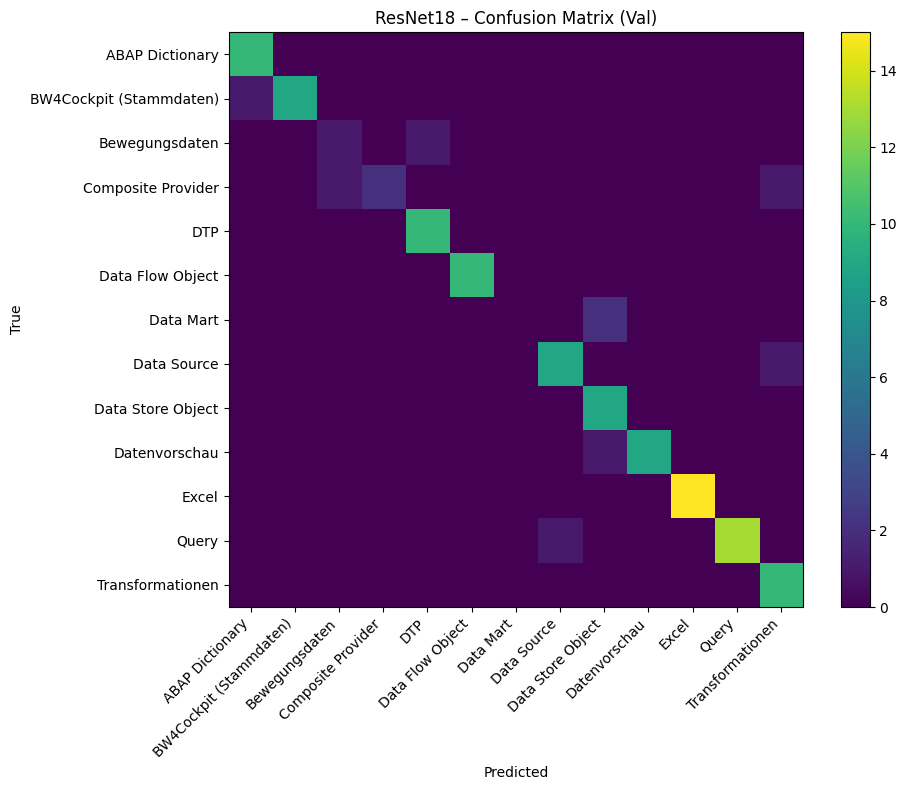

In [33]:
# 10) Bestes ResNet laden + Report + Confusion Matrix (auto GPU->CPU)
# ============================================================
watchdog(min_free_mb=1500, auto_set=True, clear=True)

device = TORCH_DEVICE

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.to(device).eval()

y_true, y_pred, acc, dev = eval_model_auto(model, val_loader, min_free_mb=1200)
print("RESNET finetuned acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("ResNet18 – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14065.0, 'allocated_mb': 417.13916015625, 'reserved_mb': 802.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14065.0, 'allocated_mb': 417.13916015625, 'reserved_mb': 802.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14065 MB >= 1500 MB).
YOLO finetuned classification_report:
                         precision    recall  f1-score   support

        ABAP Dictionary       0.83      1.00      0.91        10
BW4Cockpit (Stammdaten)       1.00      0.90      0.95        10
         Bewegungsdaten       1.00      0.50      0.67         2
     Composite Provider       1.00      1.00      1.00         4
                    DTP       0.91      1.00      0.95        10
       Data Flow Object       1.00      1.00      1.00        10
              Data Mart       0.50      

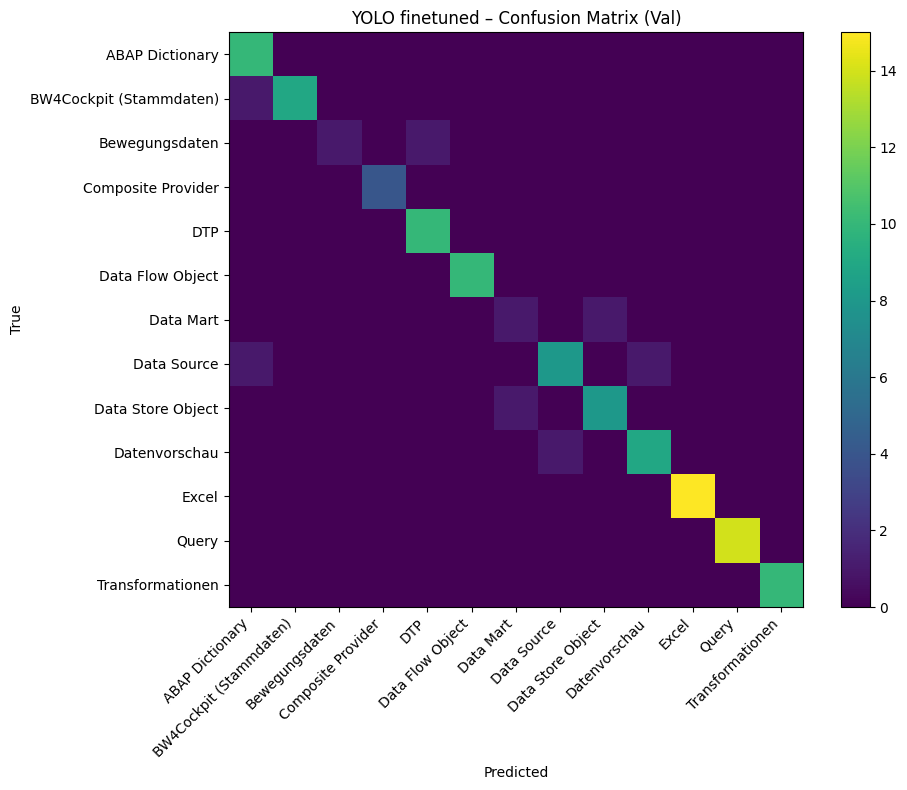

In [34]:
# 11) YOLO finetuned – Report + Confusion Matrix (stabil ohne ultralytics.predict/val)
# ============================================================
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

watchdog(min_free_mb=1500, auto_set=True, clear=True)

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean_ = (0.485, 0.456, 0.406)
        std_  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean_, std=std_),
        ])

def yolo_logits(yolo_obj, x):
    m = yolo_obj.model
    core = getattr(m, "model", None)
    out = core(x) if core is not None else m(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out

def get_idx_to_name(yolo_obj):
    names = getattr(yolo_obj, "names", None)
    if names is None and hasattr(yolo_obj, "model"):
        names = getattr(yolo_obj.model, "names", None)
    if isinstance(names, dict):
        return {int(k): v for k, v in names.items()}
    if isinstance(names, (list, tuple)):
        return {i: n for i, n in enumerate(names)}
    return None

yolo_eval_device = TORCH_DEVICE
yolo_use_amp = (yolo_eval_device.type == "cuda")

tf_yolo = get_yolo_cls_transform(224)
idx_to_name = get_idx_to_name(yolo_model)
class_to_idx = {c: i for i, c in enumerate(class_names)}

yolo_model.model.to(yolo_eval_device).eval()

val_paths = [Path(p) for p, _ in val_ds.samples]
y_true = np.array([y for _, y in val_ds.samples], dtype=int)

BATCH = 16
y_pred = np.empty(len(val_paths), dtype=int)

with torch.inference_mode():
    for start in range(0, len(val_paths), BATCH):
        chunk = val_paths[start:start + BATCH]
        imgs = [tf_yolo(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0).to(yolo_eval_device, non_blocking=yolo_use_amp)

        if yolo_use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = yolo_logits(yolo_model, x)
        else:
            logits = yolo_logits(yolo_model, x)

        top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)

        for i, pred_idx in enumerate(top1):
            if idx_to_name is not None:
                pred_name = idx_to_name.get(int(pred_idx), None)
                if pred_name in class_to_idx:
                    y_pred[start + i] = class_to_idx[pred_name]
                else:
                    y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0
            else:
                y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0

print("YOLO finetuned classification_report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm_yolo = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm_yolo)
plt.title("YOLO finetuned – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

cuda_cleanup()

In [35]:
# 12) XAI Dependencies (Captum) + Helpers
# ============================================================
import sys
from PIL import ImageFilter

try:
    import captum
    print("captum version:", captum.__version__)
except Exception:
    !{sys.executable} -m pip install -U captum
    import captum
    print("captum version:", captum.__version__)

from captum.attr import IntegratedGradients, NoiseTunnel

def show_overlay(img_pil, heatmap_2d, title, alpha=0.45, q=0.99):
    hm = np.array(heatmap_2d, dtype=np.float32)
    hm = hm - hm.min()
    vmax = np.quantile(hm, q) if hm.size else 1.0
    if vmax > 0:
        hm = np.clip(hm / vmax, 0, 1)

    img = np.array(img_pil.convert("RGB").resize((hm.shape[1], hm.shape[0])))

    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.imshow(hm, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def attr_to_heatmap(attr_tensor):
    a = attr_tensor.squeeze(0).detach().cpu().numpy()  # (3,H,W)
    hm = np.sum(np.abs(a), axis=0)                     # (H,W)
    return hm

def pick_val_image(k=0):
    p, y = val_ds.samples[k]
    return Path(p), int(y)

captum version: 0.8.0


File: ..\Work\datasets\base_split\val\ABAP Dictionary\21ffaf28aad24e4b8bf92f2643d79b91.jpeg


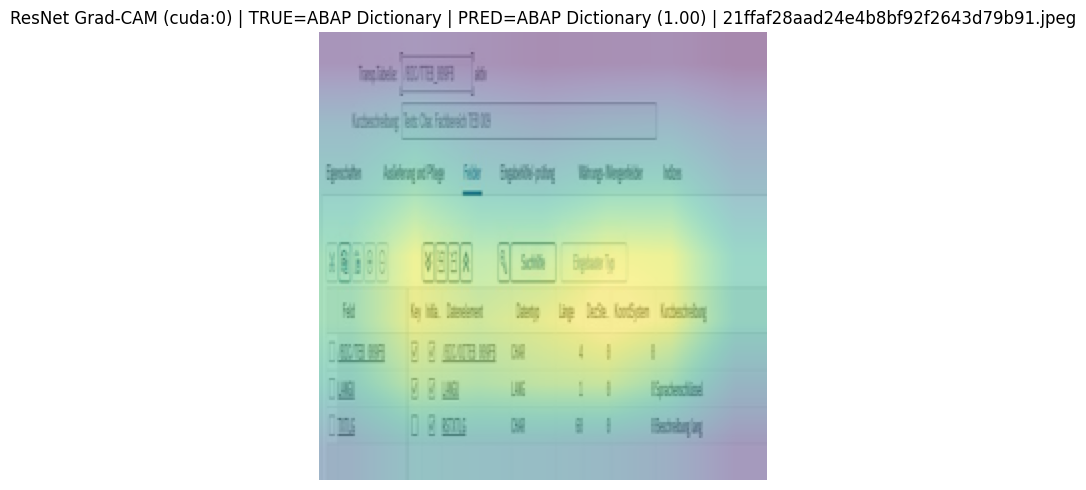

In [36]:
# 13) ResNet XAI: Grad-CAM (auto GPU->CPU)
# ============================================================
import torch.nn.functional as F

def gradcam_resnet(model, input_tensor, target_layer):
    model.eval()

    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    try:
        h2 = target_layer.register_full_backward_hook(bwd_hook)
    except Exception:
        h2 = target_layer.register_backward_hook(bwd_hook)

    input_tensor = input_tensor.requires_grad_(True)
    logits = model(input_tensor)

    pred_idx = int(logits.argmax(dim=1).item())
    probs = torch.softmax(logits.detach(), dim=1)[0]
    pred_conf = float(probs[pred_idx].item())

    model.zero_grad(set_to_none=True)
    score = logits[0, pred_idx]
    score.backward()

    h1.remove()
    h2.remove()

    act = activations[0]  # (1,C,h,w)
    grad = gradients[0]   # (1,C,h,w)

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)

    cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()

    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam, pred_idx, pred_conf

def gradcam_auto(img_path, min_free_mb=1200):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    model.to(dev).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = val_tf(img_pil).unsqueeze(0).to(dev, non_blocking=use_cuda)

    cam, pred_idx, pred_conf = gradcam_resnet(model, x, target_layer=model.layer4[-1])
    return img_pil, cam, pred_idx, pred_conf, dev

img_path, true_idx = pick_val_image(0)
img_pil, cam, pred_idx, pred_conf, dev = gradcam_auto(img_path, min_free_mb=1200)
title = f"ResNet Grad-CAM ({dev}) | TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({pred_conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, cam, title=title, alpha=0.45)

cuda_cleanup()

File: ..\Work\datasets\base_split\val\ABAP Dictionary\21ffaf28aad24e4b8bf92f2643d79b91.jpeg


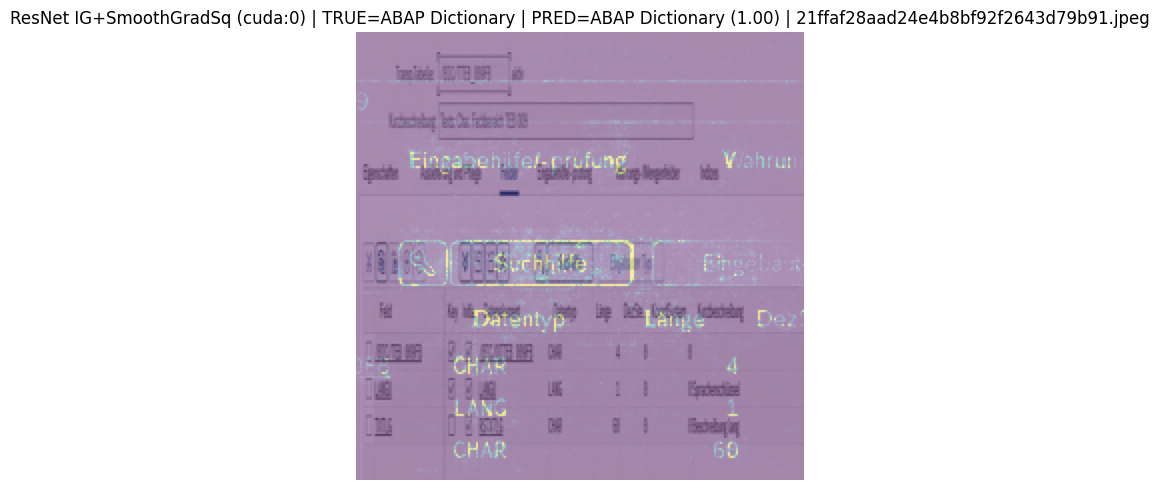

In [37]:
# 14) ResNet XAI: Integrated Gradients + SmoothGradSq (auto GPU->CPU)
# ============================================================
def ig_resnet_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24, nt_samples_gpu=8,
    n_steps_cpu=48, nt_samples_cpu=12,
    stdevs=0.15,
    use_blur_baseline=True
):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    if dev.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    model.to(dev).eval()
    img_pil = Image.open(img_path).convert("RGB")

    x = val_tf(img_pil).unsqueeze(0).to(dev)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = val_tf(blur).unsqueeze(0).to(dev)

    def forward_fn(t):
        return model(t)

    with torch.enable_grad():
        logits = forward_fn(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(forward_fn)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x, baselines=baselines, target=pred_idx,
            n_steps=n_steps, nt_type="smoothgrad_sq",
            nt_samples=nt_samples, stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, dev

img_path, true_idx = pick_val_image(0)
img_pil, attr, pred_idx, conf, dev = ig_resnet_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24,
    nt_samples_gpu=8
)
hm = attr_to_heatmap(attr)
title = f"ResNet IG+SmoothGradSq ({dev}) | TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

Val acc (CPU eval): 0.9224137931034483
Misclassified: 9
File: ..\Work\datasets\base_split\val\BW4Cockpit (Stammdaten)\0b73b5e1e2134444999308feea6afa73.png


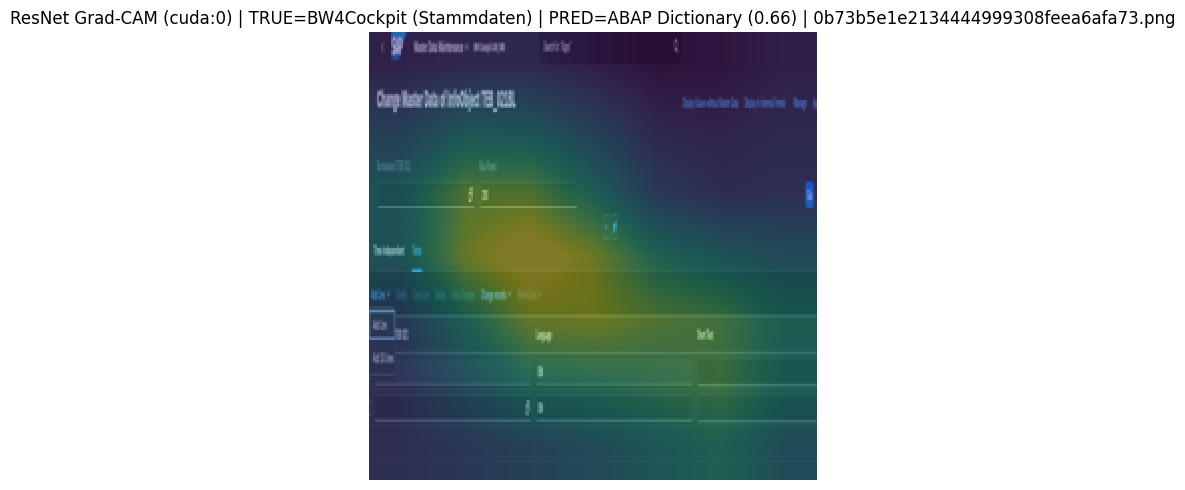

File: ..\Work\datasets\base_split\val\Bewegungsdaten\image_page16_1.png


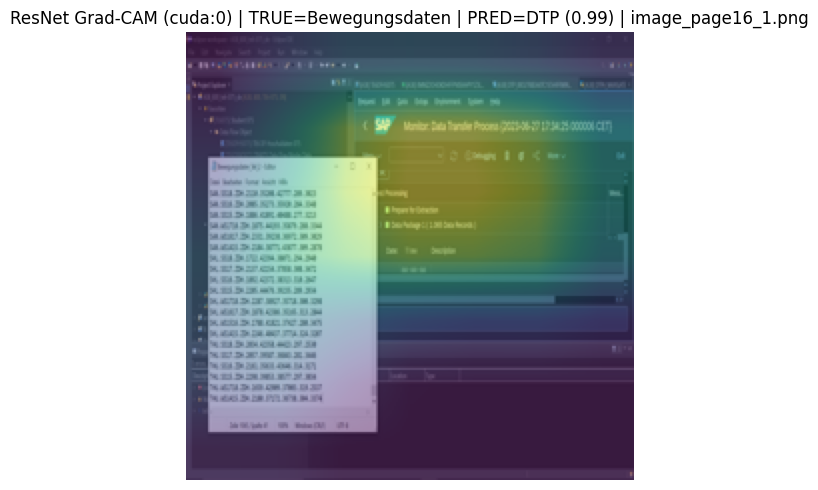

File: ..\Work\datasets\base_split\val\Composite Provider\image_page38_1.png


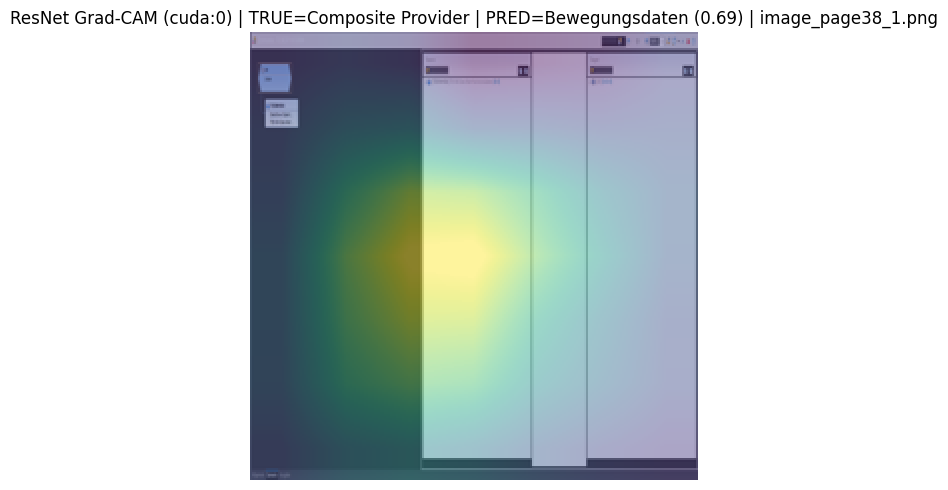

File: ..\Work\datasets\base_split\val\Composite Provider\image_page52_1 (1).png


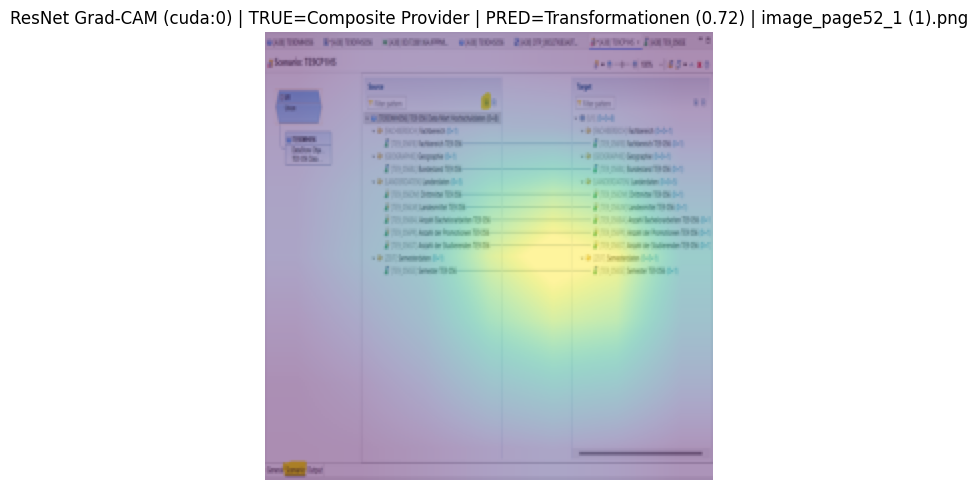

File: ..\Work\datasets\base_split\val\Data Mart\f0d3f178235448b08c727aa5e8d352ad.png


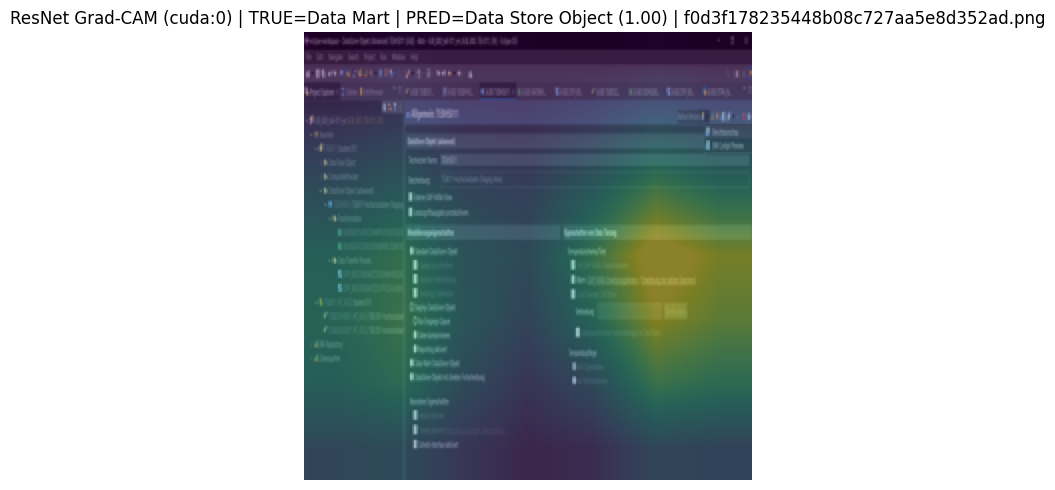

In [38]:
# 15) ResNet: Fehlklassifikationen finden + XAI (Grad-CAM) anzeigen (OOM-sicher)
# ============================================================
val_loader_cpu = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

def eval_model_cpu(model, loader):
    model_cpu = model.to("cpu").eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for x, y in loader:
            logits = model_cpu(x)
            pred = logits.argmax(dim=1).numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc

y_true, y_pred, acc = eval_model_cpu(model, val_loader_cpu)
print("Val acc (CPU eval):", acc)

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified:", len(mis_idx))

N_SHOW = 5
for k in mis_idx[:N_SHOW]:
    img_path = Path(val_ds.samples[k][0])
    true_idx = int(y_true[k])
    pred_idx_expected = int(y_pred[k])

    img_pil, cam, pred_idx_cam, pconf, dev = gradcam_auto(img_path, min_free_mb=1200)
    title = (
        f"ResNet Grad-CAM ({dev}) | TRUE={class_names[true_idx]} | "
        f"PRED={class_names[pred_idx_expected]} ({pconf:.2f}) | {img_path.name}"
    )
    print("File:", img_path)
    show_overlay(img_pil, cam, title=title, alpha=0.45)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14069.0, 'allocated_mb': 458.18505859375, 'reserved_mb': 798.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14069.0, 'allocated_mb': 458.18505859375, 'reserved_mb': 798.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14069 MB >= 2500 MB).
Using YOLO best.pt: runs\classify\train16\weights\best.pt
File: ..\Work\datasets\base_split\val\ABAP Dictionary\21ffaf28aad24e4b8bf92f2643d79b91.jpeg


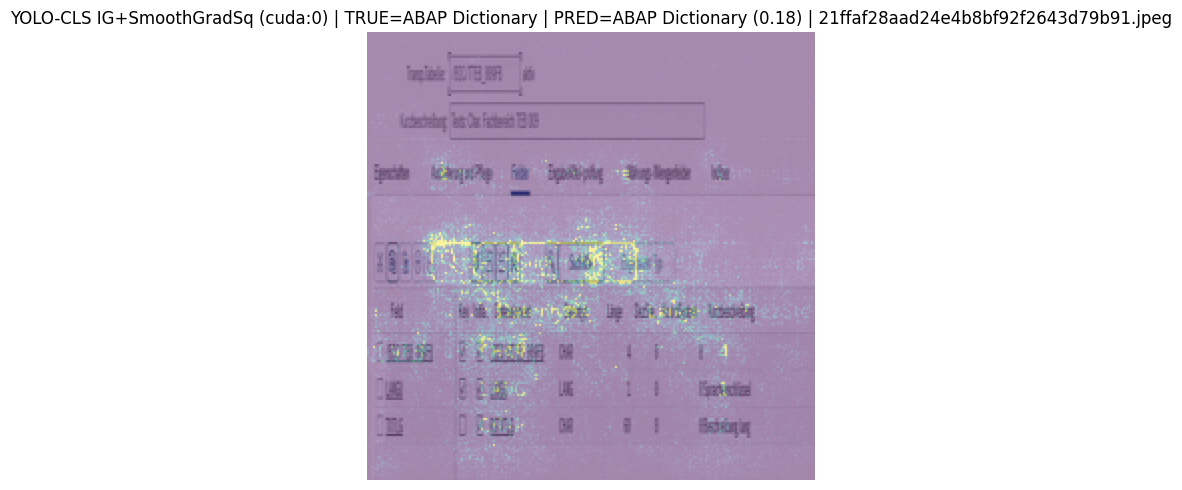

In [39]:
# 16) YOLO-CLS XAI: best.pt laden + Integrated Gradients (SmoothGradSq) (auto GPU->CPU)
# ============================================================
import numpy as np
from ultralytics import YOLO

watchdog(min_free_mb=2500, auto_set=True, clear=True)

RUNS = Path("runs") / "classify"
if not RUNS.exists():
    alt = Path("src") / "runs" / "classify"
    if alt.exists():
        RUNS = alt

best_pts = sorted(RUNS.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not best_pts:
    raise FileNotFoundError(f"Kein best.pt gefunden unter: {RUNS}")

BEST_PT = best_pts[0]
print("Using YOLO best.pt:", BEST_PT)

yolo_xai = YOLO(str(BEST_PT))

base_model = getattr(yolo_xai, "model", None)
seq = getattr(base_model, "model", None) if base_model is not None else None
if seq is None:
    if base_model is None:
        raise RuntimeError("Konnte YOLO Modell nicht extrahieren (yolo_xai.model fehlt).")
    seq = base_model

names = getattr(yolo_xai, "names", None)
if isinstance(names, dict):
    idx_to_name = {int(k): v for k, v in names.items()}
elif isinstance(names, (list, tuple)):
    idx_to_name = {i: n for i, n in enumerate(names)}
else:
    idx_to_name = {}

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean = (0.485, 0.456, 0.406)
        std  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

tf_yolo = get_yolo_cls_transform(224)

def yolo_forward(x):
    out = seq(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out

def ig_yolo_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24, nt_samples_gpu=8,
    n_steps_cpu=48, nt_samples_cpu=12,
    stdevs=0.15,
    use_blur_baseline=True
):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)

    if dev.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    seq.to(dev).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = tf_yolo(img_pil).unsqueeze(0).to(dev, non_blocking=use_cuda)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = tf_yolo(blur).unsqueeze(0).to(dev, non_blocking=use_cuda)

    with torch.enable_grad():
        logits = yolo_forward(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(yolo_forward)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x,
            baselines=baselines,
            target=pred_idx,
            n_steps=n_steps,
            nt_type="smoothgrad_sq",
            nt_samples=nt_samples,
            stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, probs, dev

img_path = Path(val_ds.samples[0][0])
true_idx = int(val_ds.samples[0][1])

img_pil, attr, pred_idx, conf, probs, dev_used = ig_yolo_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24,
    nt_samples_gpu=8,
    stdevs=0.15,
    use_blur_baseline=True
)

hm = attr_to_heatmap(attr)
pred_name = idx_to_name.get(pred_idx, str(pred_idx))
title = f"YOLO-CLS IG+SmoothGradSq ({dev_used}) | TRUE={class_names[true_idx]} | PRED={pred_name} ({conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14069.0, 'allocated_mb': 458.18505859375, 'reserved_mb': 798.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14069.0, 'allocated_mb': 458.18505859375, 'reserved_mb': 798.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14069 MB >= 1500 MB).
YOLO val acc (manual): 0.9396551724137931 | pred_device: cuda:0
YOLO Misclassified: 7
File: ..\Work\datasets\base_split\val\BW4Cockpit (Stammdaten)\0b73b5e1e2134444999308feea6afa73.png


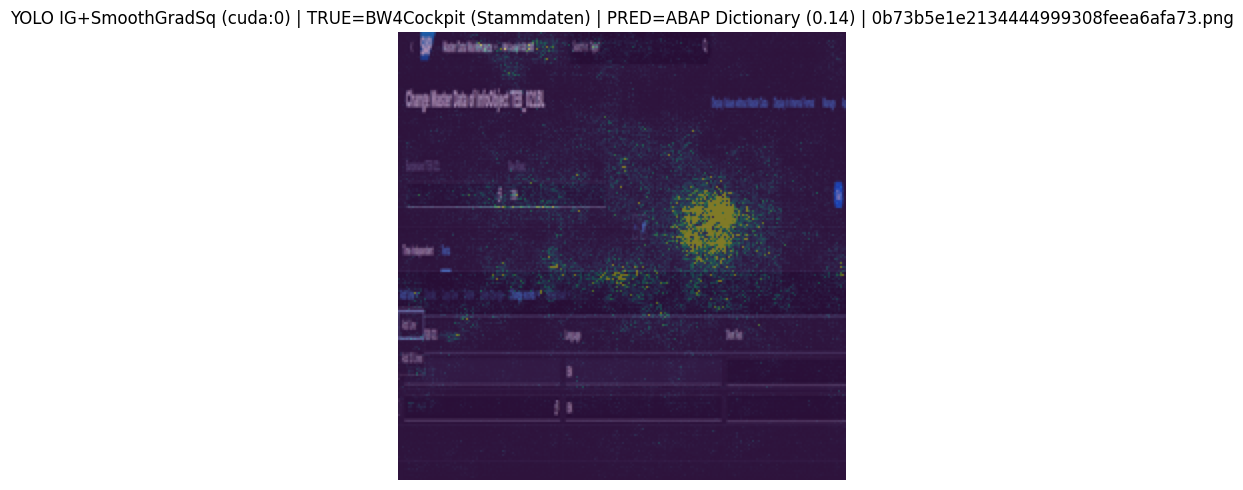

File: ..\Work\datasets\base_split\val\Bewegungsdaten\image_page16_1.png


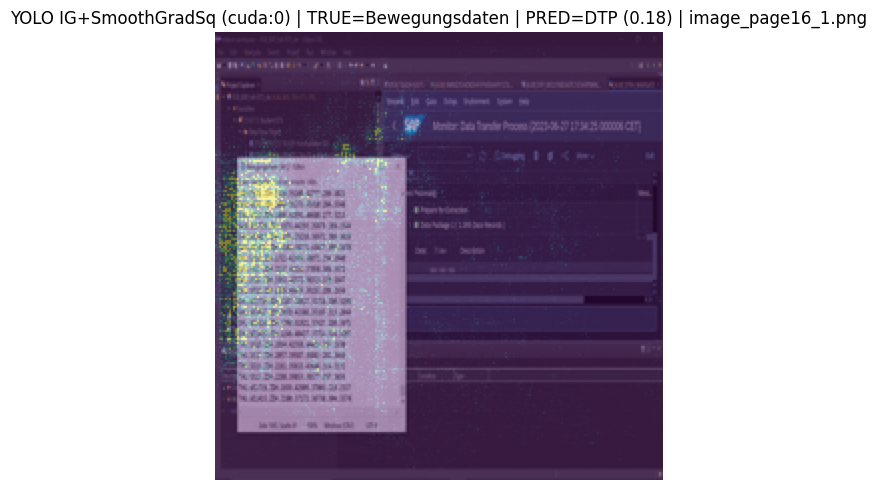

File: ..\Work\datasets\base_split\val\Data Mart\image_page28_51.jpeg


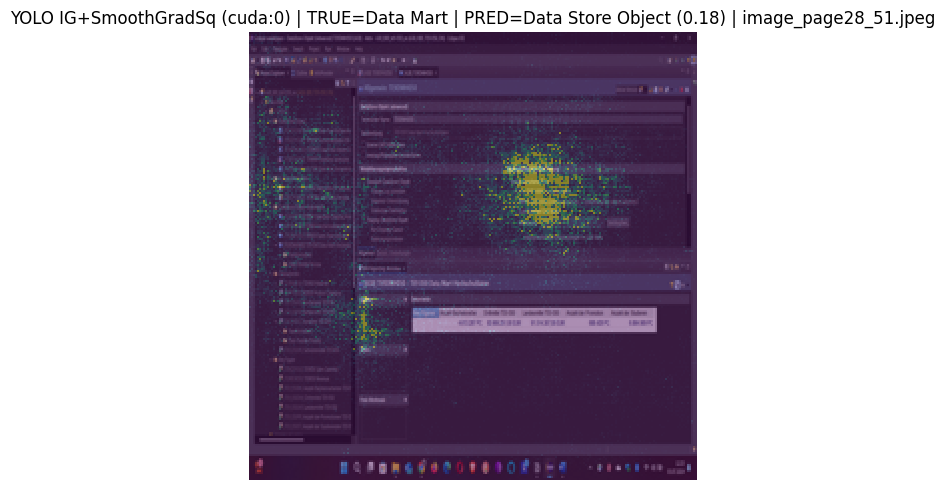

File: ..\Work\datasets\base_split\val\Data Source\3de33c44ba6a4187b578b8e45df0154a.png


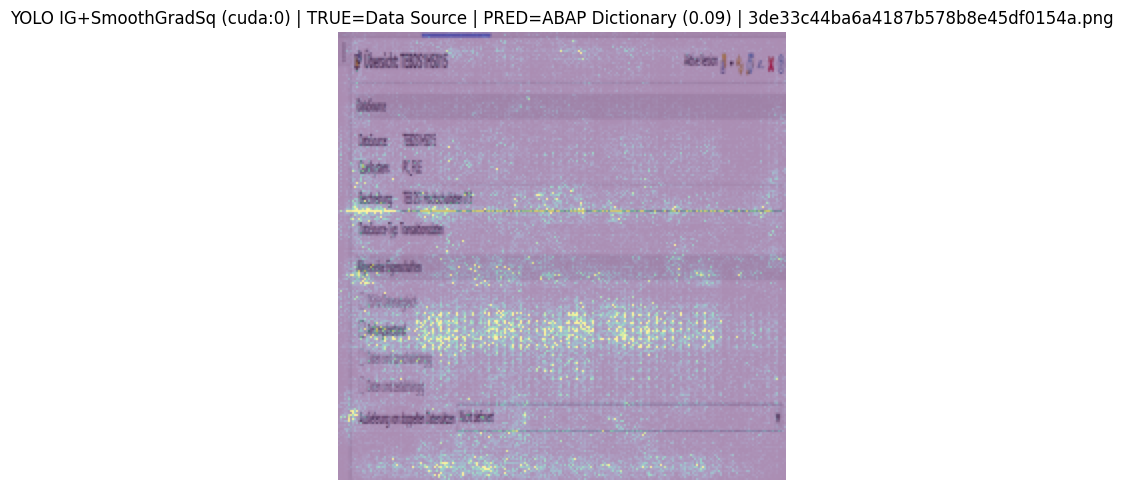

File: ..\Work\datasets\base_split\val\Data Source\ea00bd5f5c9b4ccba4260c1899a2f2d1.jpeg


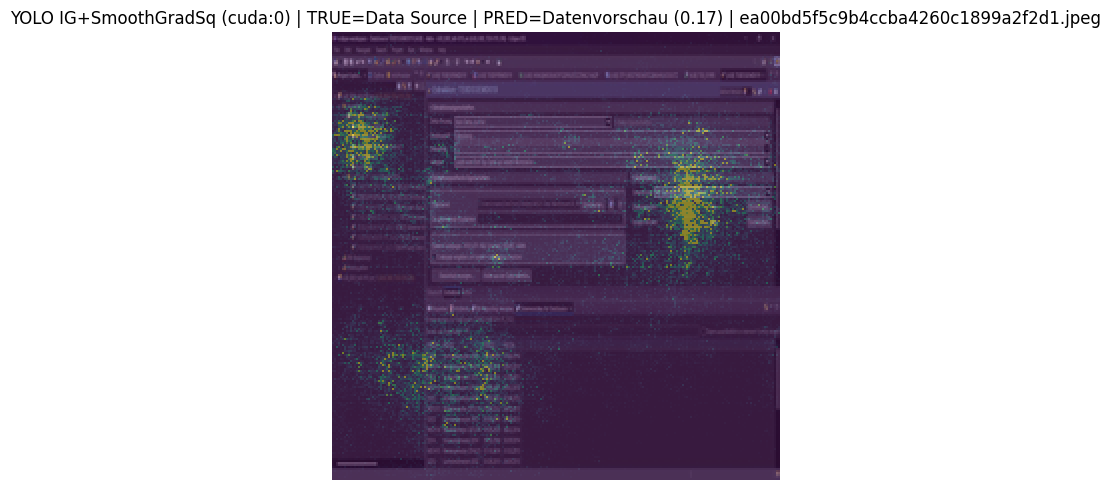

In [40]:
# 17) YOLO: Fehlklassifikationen finden + XAI (IG+SmoothGradSq) anzeigen (OOM-sicher)
# ============================================================
def yolo_predict_labels_manual(yolo_obj, val_ds, class_names, imgsz=224, batch=16, min_free_mb=1500):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)

    base = getattr(yolo_obj, "model", None)
    seq_local = getattr(base, "model", None) if base is not None else None
    if seq_local is None:
        seq_local = base
    if seq_local is None:
        raise RuntimeError("Konnte YOLO seq nicht extrahieren.")

    seq_local.to(dev).eval()

    names_local = getattr(yolo_obj, "names", None)
    if isinstance(names_local, dict):
        idx_to_name_local = {int(k): v for k, v in names_local.items()}
    elif isinstance(names_local, (list, tuple)):
        idx_to_name_local = {i: n for i, n in enumerate(names_local)}
    else:
        idx_to_name_local = {}

    tf_local = get_yolo_cls_transform(imgsz)
    class_to_idx_local = {c: i for i, c in enumerate(class_names)}

    val_paths = [Path(p) for p, _ in val_ds.samples]
    y_true = np.array([y for _, y in val_ds.samples], dtype=int)
    y_pred = np.empty(len(val_paths), dtype=int)

    def forward_local(x):
        out = seq_local(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        return out

    with torch.inference_mode():
        for start in range(0, len(val_paths), batch):
            chunk = val_paths[start:start+batch]
            imgs = [tf_local(Image.open(p).convert("RGB")) for p in chunk]
            x = torch.stack(imgs, dim=0).to(dev, non_blocking=use_cuda)

            if dev.type == "cuda":
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    logits = forward_local(x)
            else:
                logits = forward_local(x)

            top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)

            for i, pred_idx in enumerate(top1):
                pred_name = idx_to_name_local.get(int(pred_idx), None)
                if pred_name in class_to_idx_local:
                    y_pred[start+i] = class_to_idx_local[pred_name]
                else:
                    if 0 <= int(pred_idx) < len(class_names):
                        y_pred[start+i] = int(pred_idx)
                    else:
                        y_pred[start+i] = 0

    return y_true, y_pred, dev

watchdog(min_free_mb=1500, auto_set=True, clear=True)

y_true_yolo, y_pred_yolo, dev_pred = yolo_predict_labels_manual(
    yolo_xai, val_ds, class_names,
    imgsz=224,
    batch=16,
    min_free_mb=1500
)

acc_yolo = float((y_true_yolo == y_pred_yolo).mean())
print("YOLO val acc (manual):", acc_yolo, "| pred_device:", dev_pred)

mis_idx = np.where(y_true_yolo != y_pred_yolo)[0]
print("YOLO Misclassified:", len(mis_idx))

N_SHOW = 5
for k in mis_idx[:N_SHOW]:
    img_path = Path(val_ds.samples[k][0])
    true_idx = int(y_true_yolo[k])
    pred_idx = int(y_pred_yolo[k])

    img_pil, attr, pred_idx_logits, conf, probs, dev_used = ig_yolo_smooth_auto(
        img_path,
        min_free_mb=2500,
        n_steps_gpu=24,
        nt_samples_gpu=8,
        stdevs=0.15,
        use_blur_baseline=True
    )

    hm = attr_to_heatmap(attr)
    pred_name = class_names[pred_idx]

    title = (
        f"YOLO IG+SmoothGradSq ({dev_used}) | TRUE={class_names[true_idx]} | "
        f"PRED={pred_name} ({conf:.2f}) | {img_path.name}"
    )
    print("File:", img_path)
    show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()